### Univariate Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from configs.settings import project_dir

In [3]:
p_dir = project_dir()
featured_path = p_dir.FEATURE_ENGINEERED
cleaned_path = p_dir.CLEANED_DIR
print(featured_path)
cleaned_path

/home/arson/birdy/amit/noCartInsights/data/feature_engineered


PosixPath('/home/arson/birdy/amit/noCartInsights/data/cleaned')

In [4]:
orders_f = featured_path/'featured_orders.csv'
orders_df = pd.read_csv(orders_f)
orders_df.sample(2)

,order_id,customer_id,order_status,order_purchase,approved_at,delivered_carrier_date,delivered_customer_date,estimated_delivery_date,delivery_days,delivery_delay_days,is_delayed,customer_unique_id,customer_order_count,is_repeat_customer
72492,b17c37c07ccd370cd72a1884f380c532,414771711b6812e2a3bbbc867213a28b,delivered,2018-03-28 17:54:13,2018-03-28 18:08:54,2018-03-29 23:54:37,2018-04-16 18:31:51,2018-04-23,19.0,-7.0,0,f65cdf803fa5c41517f5269804281190,1,0
25245,4be354605f898bd7290366706f07d622,c32f33e3925ff7ae6c926ab877813c07,delivered,2017-06-02 22:00:00,2017-06-02 22:10:18,2017-06-05 09:51:59,2017-06-14 16:26:55,2017-06-29,11.0,-15.0,0,dfcbceb915805aad5e4f6fe5911ce661,1,0


In [5]:
## categorial col counts and distribution
orders_df['order_status'].value_counts()/len(orders_df['order_status']) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: count, dtype: float64

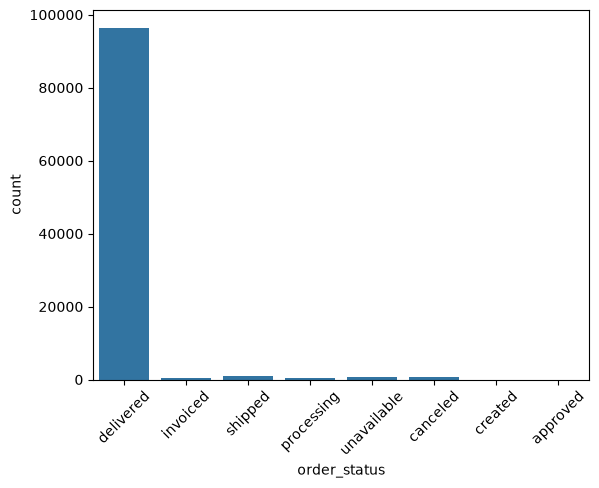

In [6]:
import seaborn as sns

sns.countplot(data=orders_df,x='order_status')
plt.xticks(rotation=45)
plt.show()


In [7]:
orders_df['is_delayed'].value_counts()/len(orders_df['order_status']) * 100

is_delayed
0    92.129001
1     7.870999
Name: count, dtype: float64

In [8]:
orders_df['is_repeat_customer'].value_counts()/len(orders_df['is_repeat_customer']) * 100

is_repeat_customer
0    93.622349
1     6.377651
Name: count, dtype: float64

### Numerical columns


In [9]:
orders_df['delivery_days'].describe()

count    96462.000000
mean        11.642968
std          9.520747
min         -7.000000
25%          6.000000
50%          9.000000
75%         15.000000
max        208.000000
Name: delivery_days, dtype: float64

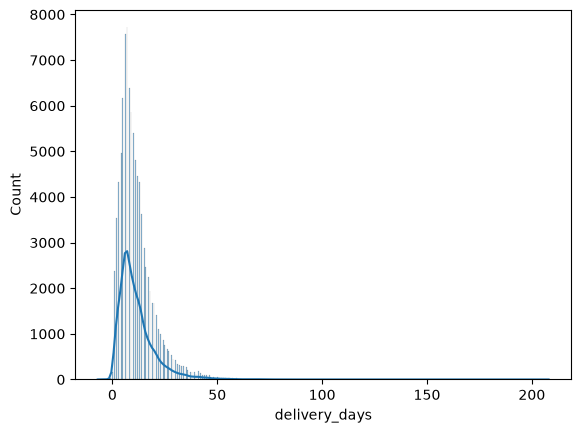

In [10]:
sns.histplot(data=orders_df,x='delivery_days',kde=True)
plt.show()

In [11]:
orders_df['delivery_delay_days'].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

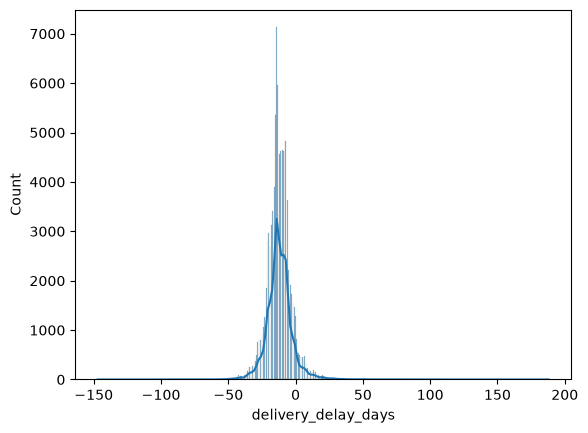

In [12]:
sns.histplot(data=orders_df,x='delivery_delay_days',kde=True)
plt.show()

### Monthly orders & revenue over time

In [13]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase,approved_at,delivered_carrier_date,delivered_customer_date,estimated_delivery_date,delivery_days,delivery_delay_days,is_delayed,customer_unique_id,customer_order_count,is_repeat_customer
90353,28804427b3bbfea6ef5a0e0de798c41a,4398328fa3c2b8ad79b777604cf9334d,delivered,2018-06-08 20:09:31,2018-06-08 21:04:08,2018-06-11 09:51:00,2018-06-16 14:24:52,2018-06-26,7.0,-10.0,0,72c7b08affaf93c2cd0a524e431102d9,1,0
78838,9abd4434524a2140bc9418988f93b4c8,3c00b418224c7d87dc77761bfd76a327,delivered,2018-03-14 16:23:40,2018-03-16 03:50:03,2018-03-16 23:15:46,2018-03-21 22:44:31,2018-04-02,5.0,-12.0,0,3fe77d4d4a0d8193e91d54e26a927964,1,0
88057,c8ebc5287c1e130db3ef5c6d50dc24eb,6eac3e5927971218ddf536df5dcff1de,delivered,2017-11-24 11:16:25,2017-11-24 13:15:33,2017-11-28 23:59:05,2017-12-21 22:28:43,2017-12-21,27.0,0.0,1,79a1c3f0f9b12a81d7ee6f2c1ff30a34,1,0
64458,c7fbc344dbbad59f3446f56555ed649b,dc79558cae15ae6f35522df09006b76f,delivered,2018-05-07 15:39:08,2018-05-07 17:29:37,2018-05-08 12:25:00,2018-05-11 19:23:30,2018-05-21,4.0,-10.0,0,6fcb3de18e2331fa5e3c0a5b9c4d5830,1,0
30294,ab85e3c92c828eb802fd91345e45d92e,4487a084654cdf96e3d715d55b48a04b,delivered,2018-05-18 23:47:11,2018-05-19 00:35:14,2018-05-21 12:41:00,2018-06-02 14:03:03,2018-06-07,14.0,-5.0,0,61fe766e454d5e750b33250035b4311d,2,1


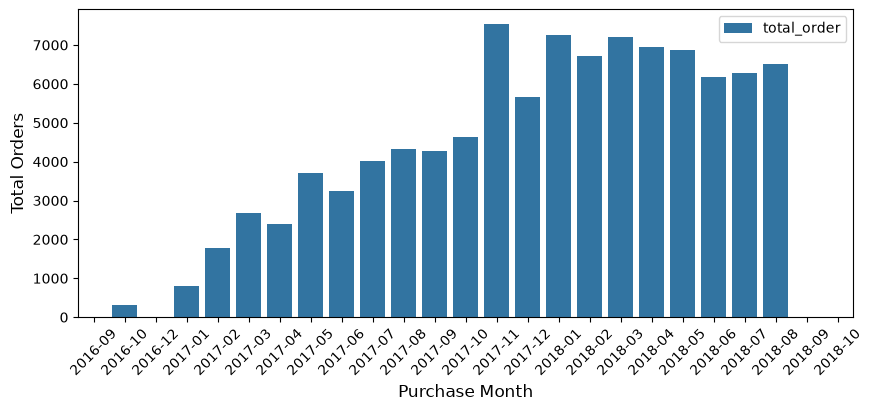

In [37]:
orders_df['order_purchase'] = pd.to_datetime(orders_df['order_purchase'])
orders_df['order_purchase_month'] = orders_df['order_purchase'].dt.to_period('M')

orders_month = (orders_df.groupby('order_purchase_month').agg(total_order = ('order_id','count')).reset_index())
orders_month['order_purchase_month'] = orders_month['order_purchase_month'].astype('str')
# visualization
plt.subplots(figsize=(10,4))
sns.barplot(data=orders_month,x='order_purchase_month',y='total_order',label='total_order')
plt.ylabel('Total Orders', fontsize=12)
plt.xlabel('Purchase Month', fontsize=12)
plt.tick_params(axis='x',rotation=45)

### Review score vs is_delayed

In [15]:
clean_dir = p_dir.CLEANED_DIR
reviews = clean_dir/'cleaned_order_reviews.csv'
reviews_df = pd.read_csv(reviews,index_col=0)
reviews_df.info()


<class 'pandas.DataFrame'>
Index: 98410 entries, 0 to 99223
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                98410 non-null  str  
 1   order_id                 98410 non-null  str  
 2   review_score             98410 non-null  int64
 3   review_comment_title     98410 non-null  str  
 4   review_comment_message   98410 non-null  str  
 5   review_creation_date     98410 non-null  str  
 6   review_answer_timestamp  98410 non-null  str  
 7   has_comment              98410 non-null  bool 
dtypes: bool(1), int64(1), str(6)
memory usage: 6.1 MB


In [16]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   order_id                 99441 non-null  str           
 1   customer_id              99441 non-null  str           
 2   order_status             99441 non-null  str           
 3   order_purchase           99441 non-null  datetime64[us]
 4   approved_at              99281 non-null  str           
 5   delivered_carrier_date   97658 non-null  str           
 6   delivered_customer_date  96476 non-null  str           
 7   estimated_delivery_date  99441 non-null  str           
 8   delivery_days            96462 non-null  float64       
 9   delivery_delay_days      96476 non-null  float64       
 10  is_delayed               99441 non-null  int64         
 11  customer_unique_id       99441 non-null  str           
 12  customer_order_count     99441 non-null  in

In [17]:
reviews_df = reviews_df.merge(
    orders_df[['order_id','is_delayed']],
    on='order_id',
    how='left'
)

reviews_df.sample()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_comment,is_delayed
60787,70fbc01f12397b8b823f7dde2911a089,53e1d3495e1dfc693b4ed16c06b15877,5,No Comment,No Comment,2018-07-11 00:00:00,2018-07-15 09:58:37,True,0


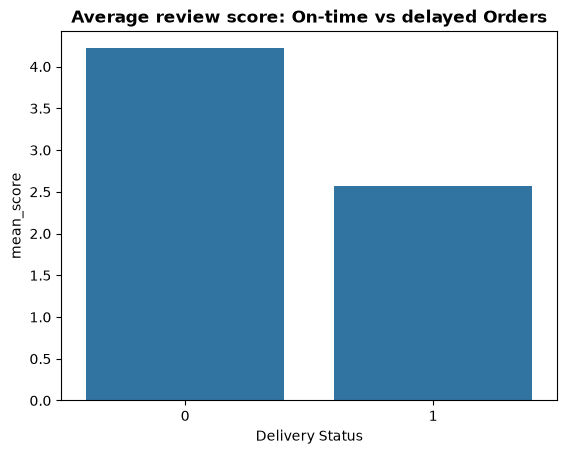

In [18]:

reviews_delay_df = (reviews_df.groupby('is_delayed').agg(mean_score=('review_score','mean')).reset_index())
reviews_delay_df

# plt.subplots(figsize=(
sns.barplot(
    data=reviews_delay_df,
    x='is_delayed',
    y='mean_score'
)
plt.title('Average review score: On-time vs delayed Orders', fontsize=12, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=10)
plt.show()

In [19]:
orders_df.sample(4)

,order_id,customer_id,order_status,order_purchase,approved_at,delivered_carrier_date,delivered_customer_date,estimated_delivery_date,delivery_days,delivery_delay_days,is_delayed,customer_unique_id,customer_order_count,is_repeat_customer,order_purchase_month
47262,3663b949b55f8b8025f32210ab79cfc9,29d45845fb05016aca8ee5964f8bba00,delivered,2018-05-11 09:52:07,2018-05-11 10:17:33,2018-05-14 14:47:00,2018-05-22 05:04:07,2018-06-04,10.0,-13.0,0,97a2eec602dfa014b956a2544749b594,1,0,2018-05
8964,f2d63838fe6815651b76e2152f1a02ee,7e37c4691de2262c9faaa4096d2d8c5a,delivered,2017-11-12 12:03:33,2017-11-14 04:10:21,2017-11-14 23:03:23,2017-11-20 20:24:39,2017-12-04,6.0,-14.0,0,e9975df17eaae863301b6c1053370725,1,0,2017-11
5276,06c94a45382f44abb2968a87bcee9bcf,79566318b6a66b5ea84699122114a934,delivered,2017-12-10 13:55:22,2017-12-10 14:10:33,2017-12-11 16:58:18,2017-12-20 12:03:41,2018-01-05,9.0,-16.0,0,4e95c3db873ad0daa03d9a233362396d,1,0,2017-12
87443,03c6fd082fce47bdd5e0dc1f81a9626f,3347f8d33927f9bb5159b2aa82b3d622,delivered,2018-05-12 20:50:47,2018-05-12 21:15:55,2018-05-15 07:55:00,2018-06-05 18:06:34,2018-06-11,23.0,-6.0,0,dbbdf30a9af9996ef9667badfb0c4aa1,1,0,2018-05


### top 10 categories by mean order value

In [20]:
products = featured_path/'featured_products.csv'
products_df = pd.read_csv(products)
products_df.sample()

,product_id,category_name,name_length,description_length,photos_qty,weight_g,category_name_eng,volume
26347,8df56ba30e76d09f57ca93ee364616a0,cama_mesa_banho,57.0,262.0,1.0,1600.0,bed_bath_table,23625.0


In [21]:
order_items = featured_path/'featured_order_items.csv'
order_items_df = pd.read_csv(order_items,index_col=0)
order_items_df.sample()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_amount,seller_revenue,seller_order_count
110180,fa5a7d839b49e173198586f7366939cb,1,f71f42e2381752836563b70beb542f80,85d9eb9ddc5d00ca9336a2219c97bb13,2017-06-12 12:42:03,31.9,16.79,48.69,24029.58,522


In [22]:
# merging the order_items and products on product_id 
order_items_df = order_items_df.merge(
    products_df[['product_id','category_name_eng']],
    on='product_id',
    how='left'

)

order_items_df.sample(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_amount,seller_revenue,seller_order_count,category_name_eng
18209,29c56706d0442edbc19623391d958d7f,1,127c0cde3ea832c4c4901159cf902d0e,d5ba419e26d246a0719437cf37d9b46d,2018-05-17 03:10:37,129.9,9.26,139.16,4581.51,35,computers_accessories
31976,487e6e67e10e5756f886f5994439c22f,1,0e14941c183946f60e3b86585d05f984,00720abe85ba0859807595bbf045a33b,2018-06-12 15:51:50,14.8,12.19,26.99,1323.48,26,housewares


In [23]:
# groupby category_name_eg nd mean the total amount, to get the top categories
top_categories_amount = (order_items_df.groupby(
    'category_name_eng'
).agg(
    mean_value=(
        'total_amount','mean'
    )
).reset_index().sort_values(by='mean_value',ascending=False))
top_categories_amount

,category_name_eng,mean_value
14,computers,1146.795222
64,small_appliances_home_oven_and_coffee,660.441711
45,home_appliances_2,520.663529
0,agro_industry_and_commerce,369.689009
56,musical_instruments,309.025544
...,...,...
37,food_drink,70.818237
11,cds_dvds_musicals,68.213571
23,diapers_and_hygiene,54.904359
35,flowers,48.451818


In [24]:
top_categories_revenue_mean = (
    order_items_df.groupby('category_name_eng').agg(
        mean_revenue=(
            'seller_revenue','mean'
        )
    ).reset_index().sort_values(by='mean_revenue',ascending=False)
)
top_categories_revenue_mean

,category_name_eng,mean_revenue
46,home_comfort_2,205430.979333
14,computers,185188.541823
57,office_furniture,181782.290686
47,home_confort,145905.945668
70,watches_gifts,132260.819808
...,...,...
58,party_supplies,3967.586744
10,books_technical,3600.995056
12,christmas_supplies,3363.320458
9,books_imported,2552.982333


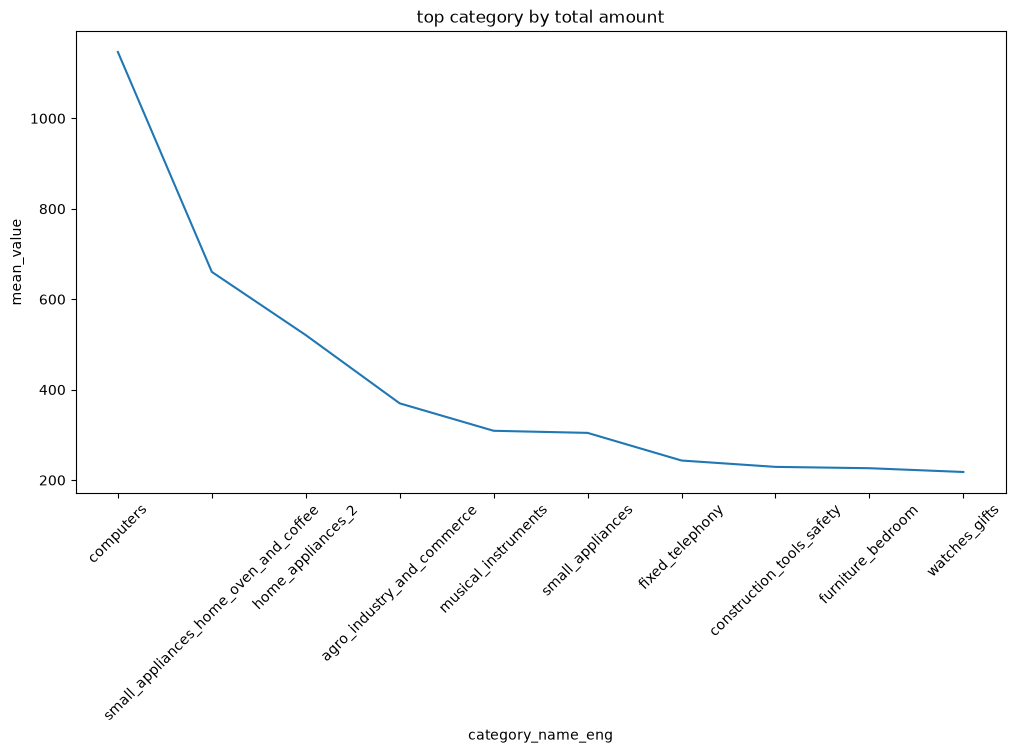

In [25]:
ax, fig = plt.subplots(figsize=(12,6))
top_10 = top_categories_amount.nlargest(10,'mean_value')
sns.lineplot(
    data=top_10,
    x='category_name_eng',
    y='mean_value'
)
plt.title('top category by total amount')
plt.tick_params(axis='x',rotation=45)

### top 10 by total revenue


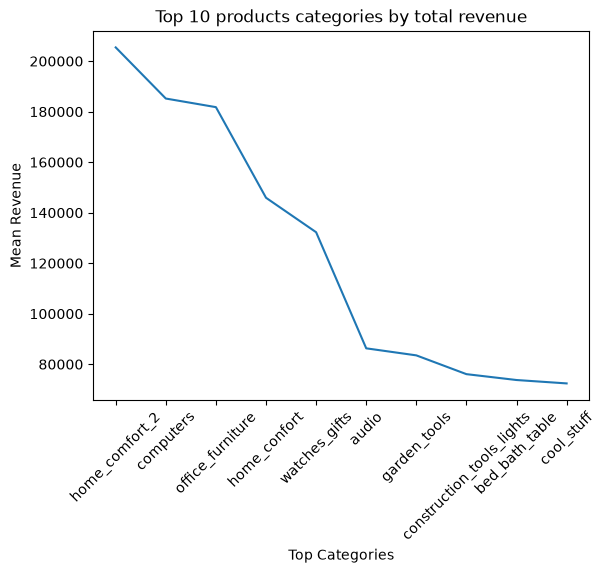

In [27]:
top_10_revenue = top_categories_revenue_mean.nlargest(10,'mean_revenue')

sns.lineplot(
    data=top_10_revenue,
    x='category_name_eng',
    y='mean_revenue'
)
plt.ylabel("Mean Revenue")
plt.xlabel("Top Categories")
plt.title('Top 10 products categories by total revenue')
plt.tick_params(axis='x',rotation=45)

In [28]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase,approved_at,delivered_carrier_date,delivered_customer_date,estimated_delivery_date,delivery_days,delivery_delay_days,is_delayed,customer_unique_id,customer_order_count,is_repeat_customer,order_purchase_month
71392,be7f750bcb350e7e289e828efc763466,2004beab18003b04d2e2603e1055d589,delivered,2018-01-16 11:06:55,2018-01-17 03:38:46,2018-01-18 22:17:19,2018-01-24 10:42:30,2018-02-07,7.0,-14.0,0,d936da095a235937dbcc81ab08bac901,1,0,2018-01
16096,a14cb0a59ebadf133edc5ccb9ccfc0e7,f5798cfca279c6631c01420e1dffe011,delivered,2018-06-26 15:38:05,2018-06-26 15:56:48,2018-06-26 15:18:00,2018-06-28 21:38:33,2018-07-12,2.0,-14.0,0,ef52bef059c1a937c54ea492baff2533,1,0,2018-06
82454,ee605d7a4828562e22bb239357c81830,9f44bc42812285f544a70b336a157b4b,delivered,2018-05-15 14:53:02,2018-05-15 15:30:57,2018-05-16 13:53:00,2018-05-22 19:21:02,2018-06-05,7.0,-14.0,0,f2ca3b4e030373f8dba54a6903022c65,1,0,2018-05
5234,6b026a0a382ef161c512318a3b1edbe1,13fcc139e9162c05fb256d3bd6fa16f8,delivered,2017-12-24 19:23:28,2017-12-24 19:30:26,2017-12-28 18:48:58,2017-12-29 14:22:51,2018-01-15,4.0,-17.0,0,f9df625a68cf59005f7683f8d096a7a0,1,0,2017-12
18971,13d840efe9026dc20ab05e59663dff7f,6559eb1529fa374ff7f71a8f2b1e5405,delivered,2017-11-10 17:01:30,2017-11-10 17:15:36,2017-11-13 16:54:09,2017-11-30 16:00:22,2017-11-30,19.0,0.0,1,3f1964830dc088f26df369c464e6ad2b,1,0,2017-11


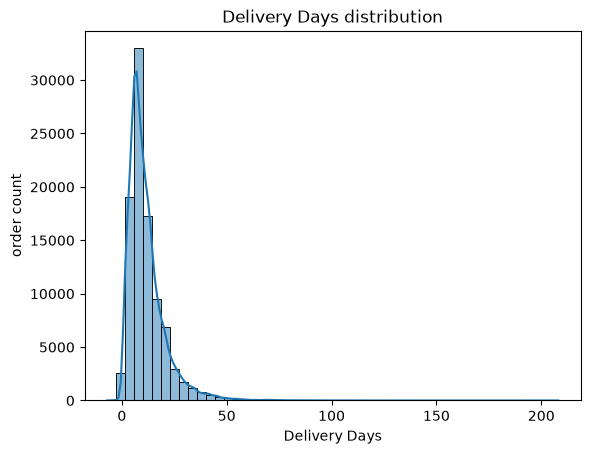

In [34]:
sns.histplot(
    data=orders_df,x='delivery_days',bins=50,kde=True
)
plt.xlabel('Delivery Days')
plt.ylabel('order count')
plt.title('Delivery Days distribution')
plt.show()

### Actual Delivery Days and Estimated delivery Days distribution

### summary of key findings

- 97% orders are delivered, ~7% are delayed
- average delivery time is ~12 days
- delayed orders have significantly lower review scores (t-test p ≈ 0)
- bed_bath_table and health_beauty are top revenue categories
- 93% customers are new, only 7% are repeat customers

In [ ]:
orders_df[["order_value","delivery_days","is_delayed"]].describe()